# 07 — Robustness Checks

This notebook implements sensitivity analyses to validate the main findings:

1. **Placebo Tests** — Assign fake treatment dates and check for spurious effects
2. **Leave-One-Out** — Drop each state to check for influential observations
3. **Alternative Control Groups** — Restrict to border states or similar demographics
4. **Varying Pre/Post Windows** — Sensitivity to period definitions
5. **Dose-Response** — Do larger coverage gains → larger health effects?

**Input:** `data/processed/analysis_panel.csv`  
**Output:** Robustness figures and tables

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS
import warnings
import os

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 150,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

os.makedirs('../figures', exist_ok=True)
os.makedirs('../tables', exist_ok=True)

panel = pd.read_csv('../data/processed/analysis_panel.csv')
print(f"Panel: {panel.shape}")

# Identify outcome and control variables
outcome_candidates = [
    'allcause_age_adj_rate', 'diabetes_age_adj_rate',
    'maternal_age_adj_rate', 'diabetes_prevalence',
    'low_birth_weight_pct', 'poverty_rate', 'median_household_income'
]
outcome_vars = [c for c in outcome_candidates if c in panel.columns and panel[c].notna().sum() > 100]

control_vars = [c for c in ['median_household_income', 'poverty_rate', 'pct_white', 'pct_black', 'pct_hispanic']
                if c in panel.columns and panel[c].notna().sum() > 100]

print(f"Outcomes: {outcome_vars}")
print(f"Controls: {control_vars}")

# Pick primary outcome for detailed tests
PRIMARY_OUTCOME = outcome_vars[0] if outcome_vars else None
print(f"Primary outcome for detailed tests: {PRIMARY_OUTCOME}")

Panel: (663, 32)
Outcomes: ['allcause_age_adj_rate', 'diabetes_age_adj_rate', 'maternal_age_adj_rate', 'diabetes_prevalence', 'poverty_rate', 'median_household_income']
Controls: ['median_household_income', 'poverty_rate', 'pct_white', 'pct_black', 'pct_hispanic']
Primary outcome for detailed tests: allcause_age_adj_rate


---
## 1. Placebo Tests

If our DiD design is valid, assigning **fake** treatment years should produce null effects. We test this by:
- Restricting to pre-treatment data only (2010–2013)
- Assigning a fake "expansion" in 2012
- Running the same DiD specification

**Expected result:** The placebo DiD estimate should be statistically insignificant (~0).

In [2]:
def run_placebo_test(panel, outcome_var, fake_year=2012):
    """
    Placebo test: restrict to pre-period, assign fake treatment.
    """
    # Only pre-treatment period
    df = panel[
        (panel['year'] < 2014) &
        (panel['expansion_year'].isin([2014, 0])) &  # Clean comparison
        (panel[outcome_var].notna())
    ].copy()
    
    df['fake_post'] = (df['year'] >= fake_year).astype(int)
    df['treat'] = (df['expansion_year'] == 2014).astype(int)
    df['fake_did'] = df['treat'] * df['fake_post']
    
    formula = f'{outcome_var} ~ treat + fake_post + fake_did'
    model = smf.ols(formula, data=df).fit(
        cov_type='cluster', cov_kwds={'groups': df['state_fips']}
    )
    
    return {
        'fake_year': fake_year,
        'coef': model.params['fake_did'],
        'se': model.bse['fake_did'],
        'pvalue': model.pvalues['fake_did'],
        'ci_lower': model.conf_int().loc['fake_did', 0],
        'ci_upper': model.conf_int().loc['fake_did', 1]
    }

Placebo Tests: allcause_age_adj_rate


,fake_year,coef,se,pvalue,ci_lower,ci_upper
0,2011,8.2157,4.2883,0.0554,-0.1893,16.6206
1,2012,1.5117,2.9383,0.6069,-4.2474,7.2707
2,2013,-0.1075,3.7371,0.9770,-7.4321,7.2170


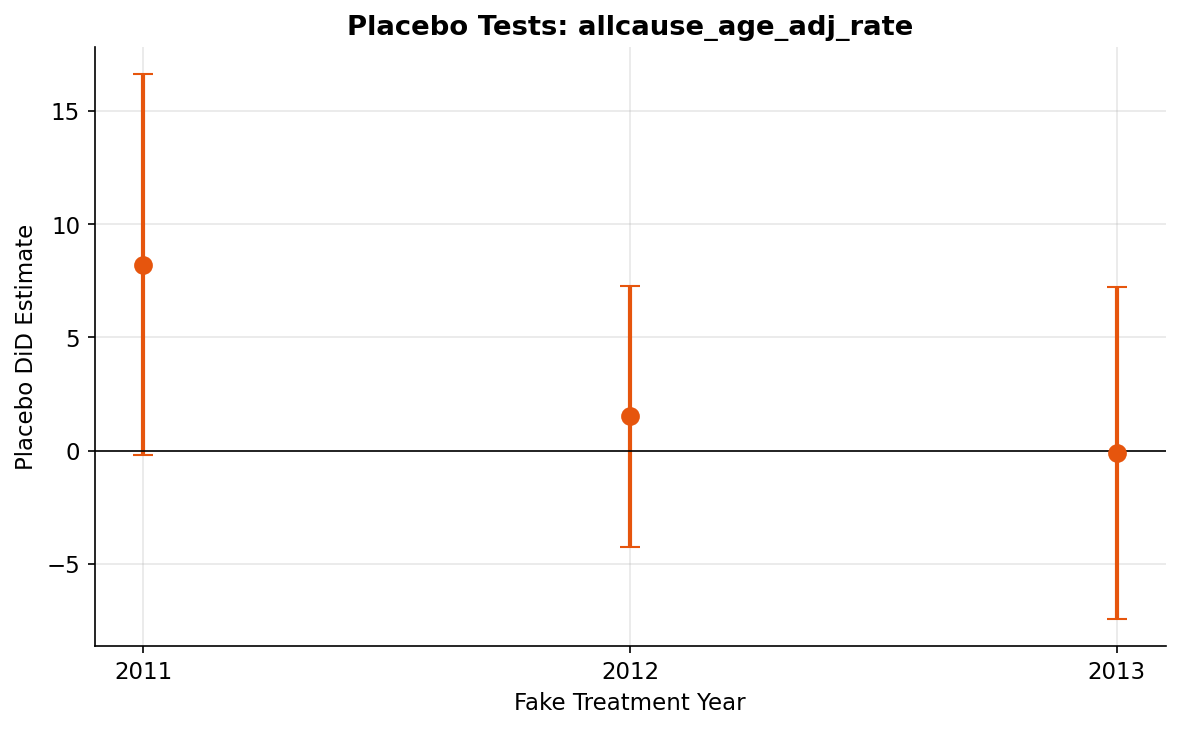


✅ All placebo estimates are insignificant — supports parallel trends.


In [3]:
if PRIMARY_OUTCOME:
    # Run placebo for multiple fake years
    placebo_results = []
    for fake_yr in [2011, 2012, 2013]:
        try:
            result = run_placebo_test(panel, PRIMARY_OUTCOME, fake_year=fake_yr)
            placebo_results.append(result)
        except Exception as e:
            print(f"Placebo {fake_yr} failed: {e}")
    
    if placebo_results:
        placebo_df = pd.DataFrame(placebo_results)
        
        print(f"Placebo Tests: {PRIMARY_OUTCOME}")
        print("=" * 60)
        display(placebo_df.round(4))
        
        # Plot
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.errorbar(placebo_df['fake_year'], placebo_df['coef'],
                    yerr=1.96 * placebo_df['se'],
                    fmt='o', color='#e6550d', capsize=5, markersize=8, linewidth=2)
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
        ax.set_xlabel('Fake Treatment Year')
        ax.set_ylabel('Placebo DiD Estimate')
        ax.set_title(f'Placebo Tests: {PRIMARY_OUTCOME}', fontweight='bold')
        ax.set_xticks(placebo_df['fake_year'])
        
        plt.tight_layout()
        plt.savefig('../figures/placebo_tests.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        # Interpret
        any_sig = (placebo_df['pvalue'] < 0.05).any()
        if not any_sig:
            print("\n✅ All placebo estimates are insignificant — supports parallel trends.")
        else:
            print("\n⚠️  Some placebo estimates are significant — potential pre-trend concern.")
else:
    print("No outcome variable available for placebo tests.")

---
## 2. Leave-One-Out Analysis

Sequentially drop each state and re-estimate the TWFE model to check whether any single state is driving the results.

In [4]:
def run_leave_one_out(panel, outcome_var):
    """
    Drop each state one at a time and re-estimate TWFE.
    """
    results = []
    states = panel['state'].unique()
    
    for drop_state in states:
        df = panel[
            (panel['state'] != drop_state) &
            (panel[outcome_var].notna())
        ].copy()
        
        df = df.set_index(['state_fips', 'year'])
        y = df[outcome_var]
        X = df[['post_expansion']]
        
        mask = X.notna().all(axis=1) & y.notna()
        
        try:
            model = PanelOLS(y[mask], X[mask],
                             entity_effects=True, time_effects=True
                             ).fit(cov_type='clustered', cluster_entity=True)
            
            results.append({
                'dropped_state': drop_state,
                'coef': model.params['post_expansion'],
                'se': model.std_errors['post_expansion'],
                'pvalue': model.pvalues['post_expansion']
            })
        except:
            pass
    
    return pd.DataFrame(results)

Running leave-one-out for: allcause_age_adj_rate
This may take a minute...



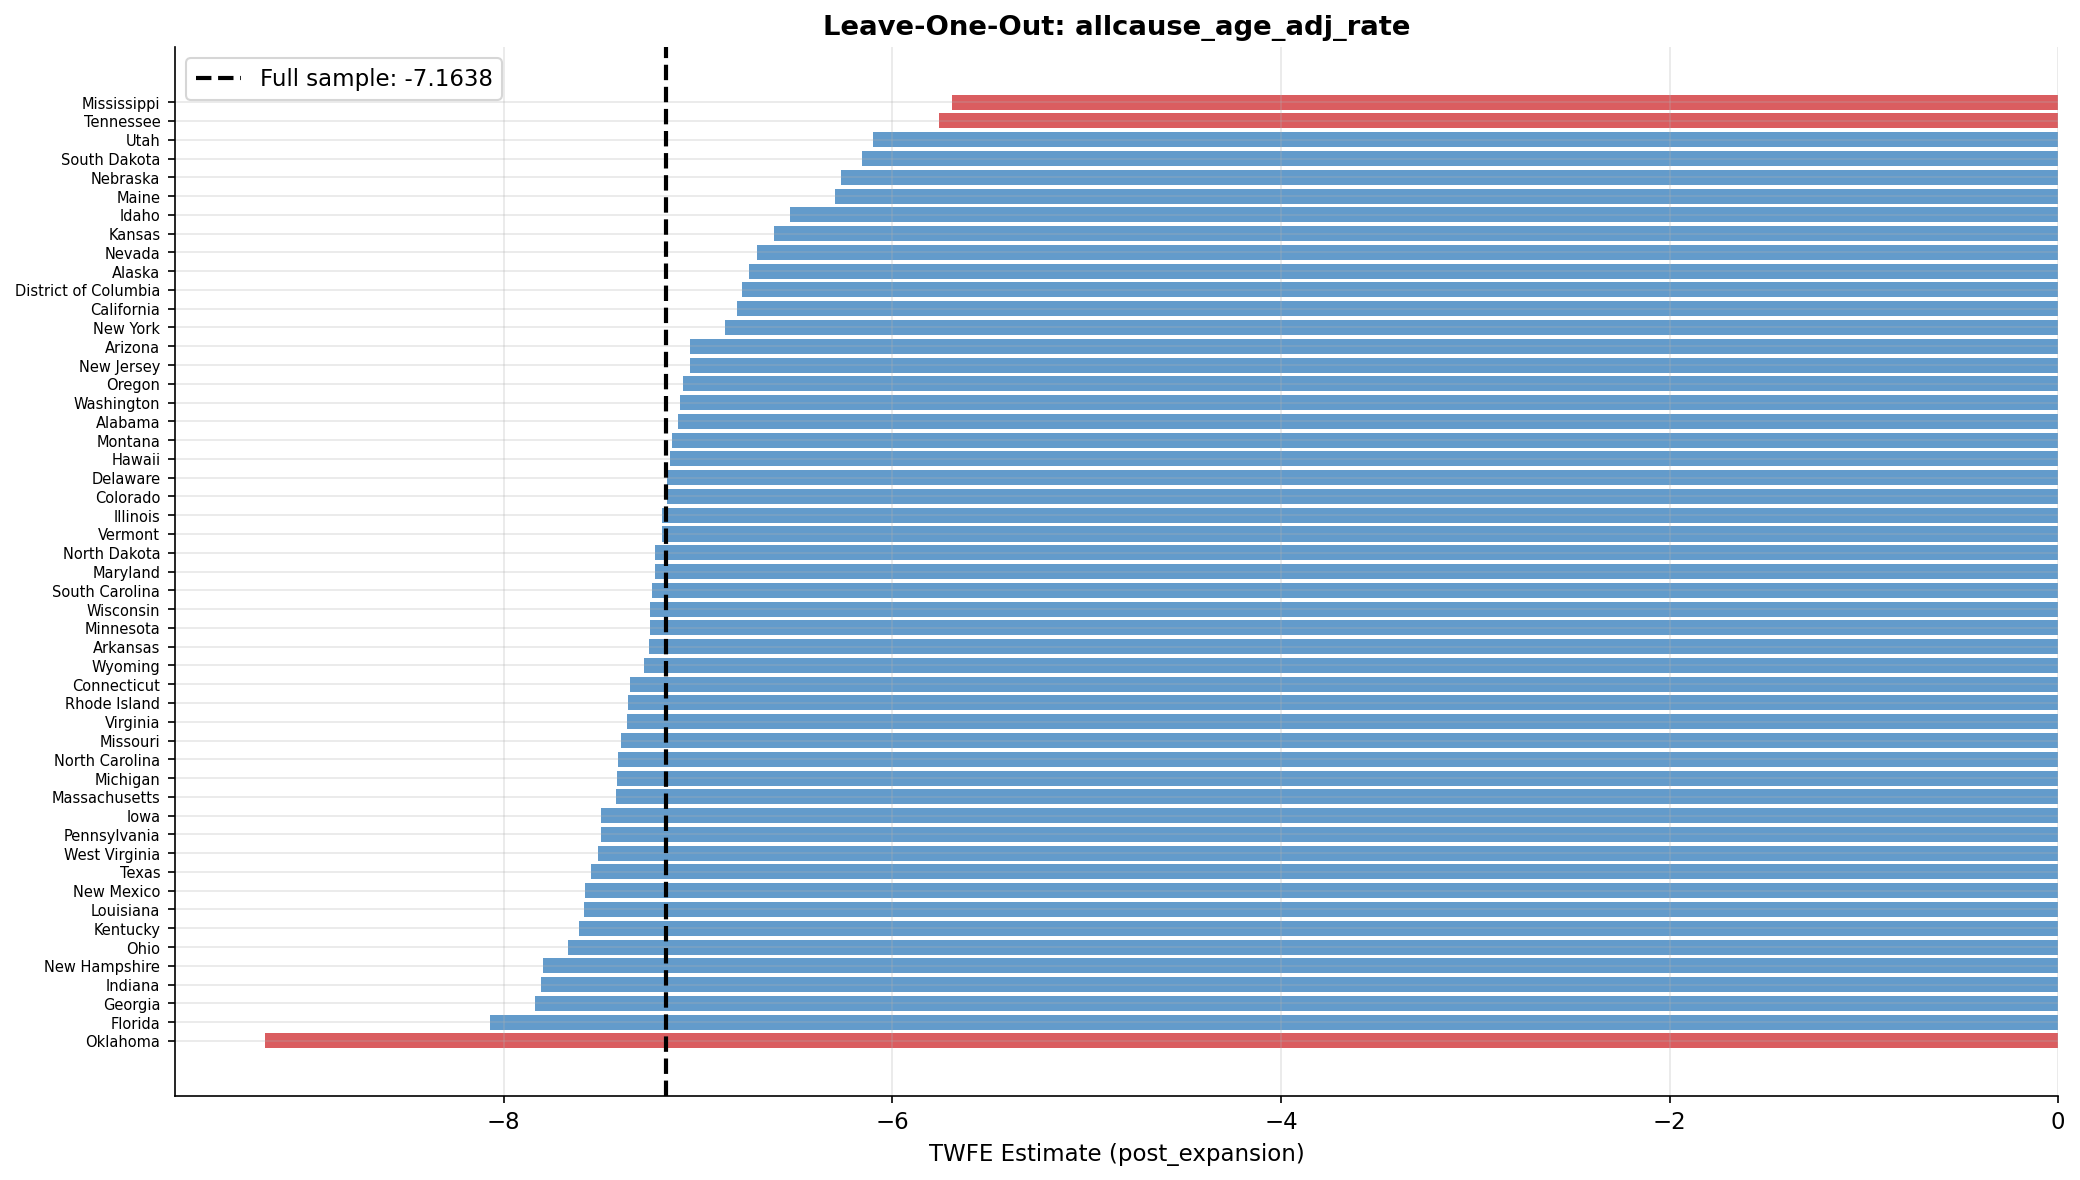


Most influential states (dropping changes estimate most):


,dropped_state,coef,deviation
36,Oklahoma,-9.2308,2.0670
24,Mississippi,-5.6926,1.4712
42,Tennessee,-5.7608,1.4030
44,Utah,-6.1023,1.0615
41,South Dakota,-6.1579,1.0059



Saved: tables/leave_one_out.csv


In [5]:
if PRIMARY_OUTCOME:
    print(f"Running leave-one-out for: {PRIMARY_OUTCOME}")
    print("This may take a minute...\n")
    
    loo_df = run_leave_one_out(panel, PRIMARY_OUTCOME)
    
    if len(loo_df) > 0:
        # Full sample estimate for reference
        df_full = panel[panel[PRIMARY_OUTCOME].notna()].copy().set_index(['state_fips', 'year'])
        full_model = PanelOLS(
            df_full[PRIMARY_OUTCOME], df_full[['post_expansion']],
            entity_effects=True, time_effects=True
        ).fit(cov_type='clustered', cluster_entity=True)
        full_estimate = full_model.params['post_expansion']
        
        # Plot
        fig, ax = plt.subplots(figsize=(14, 8))
        
        loo_sorted = loo_df.sort_values('coef')
        colors = ['#cb181d' if abs(row['coef'] - full_estimate) > 2 * loo_df['coef'].std()
                  else '#2171b5' for _, row in loo_sorted.iterrows()]
        
        ax.barh(range(len(loo_sorted)), loo_sorted['coef'], color=colors, alpha=0.7)
        ax.axvline(x=full_estimate, color='black', linestyle='--', linewidth=2,
                   label=f'Full sample: {full_estimate:.4f}')
        ax.set_yticks(range(len(loo_sorted)))
        ax.set_yticklabels(loo_sorted['dropped_state'], fontsize=7)
        ax.set_xlabel('TWFE Estimate (post_expansion)')
        ax.set_title(f'Leave-One-Out: {PRIMARY_OUTCOME}', fontweight='bold')
        ax.legend()
        
        plt.tight_layout()
        plt.savefig('../figures/leave_one_out.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        # Flag influential states
        loo_df['deviation'] = abs(loo_df['coef'] - full_estimate)
        top_influential = loo_df.nlargest(5, 'deviation')
        print("\nMost influential states (dropping changes estimate most):")
        display(top_influential[['dropped_state', 'coef', 'deviation']].round(4))
        
        # Save
        loo_df.to_csv('../tables/leave_one_out.csv', index=False)
        print("\nSaved: tables/leave_one_out.csv")
else:
    print("No outcome variable available.")

---
## 3. Varying Pre/Post Windows

Test sensitivity of results to different definitions of the pre and post periods.

In [6]:
def run_window_sensitivity(panel, outcome_var, windows):
    """
    Re-estimate TWFE for different time windows.
    """
    results = []
    
    for start_yr, end_yr in windows:
        df = panel[
            (panel['year'].between(start_yr, end_yr)) &
            (panel[outcome_var].notna())
        ].copy()
        
        df = df.set_index(['state_fips', 'year'])
        y = df[outcome_var]
        X = df[['post_expansion']]
        mask = X.notna().all(axis=1) & y.notna()
        
        try:
            model = PanelOLS(y[mask], X[mask],
                             entity_effects=True, time_effects=True
                             ).fit(cov_type='clustered', cluster_entity=True)
            
            results.append({
                'window': f'{start_yr}–{end_yr}',
                'coef': model.params['post_expansion'],
                'se': model.std_errors['post_expansion'],
                'ci_lower': model.conf_int().loc['post_expansion', 'lower'],
                'ci_upper': model.conf_int().loc['post_expansion', 'upper'],
                'pvalue': model.pvalues['post_expansion'],
                'n_obs': model.nobs
            })
        except Exception as e:
            print(f"Window {start_yr}-{end_yr} failed: {e}")
    
    return pd.DataFrame(results)

Window Sensitivity: allcause_age_adj_rate


,window,coef,se,ci_lower,ci_upper,pvalue,n_obs
0,2010–2017,0.9637,3.1191,-5.1709,7.0983,0.7575,408
1,2010–2019,0.0542,3.2403,-6.3138,6.4223,0.9866,510
2,2010–2022,-7.1638,4.1717,-15.3568,1.0291,0.0864,663
3,2011–2022,-7.9748,4.1668,-16.1597,0.2101,0.0562,612
4,2012–2022,-7.5039,4.6441,-16.6283,1.6205,0.1068,561
5,2010–2020,-4.5167,3.7201,-11.8258,2.7923,0.2253,561


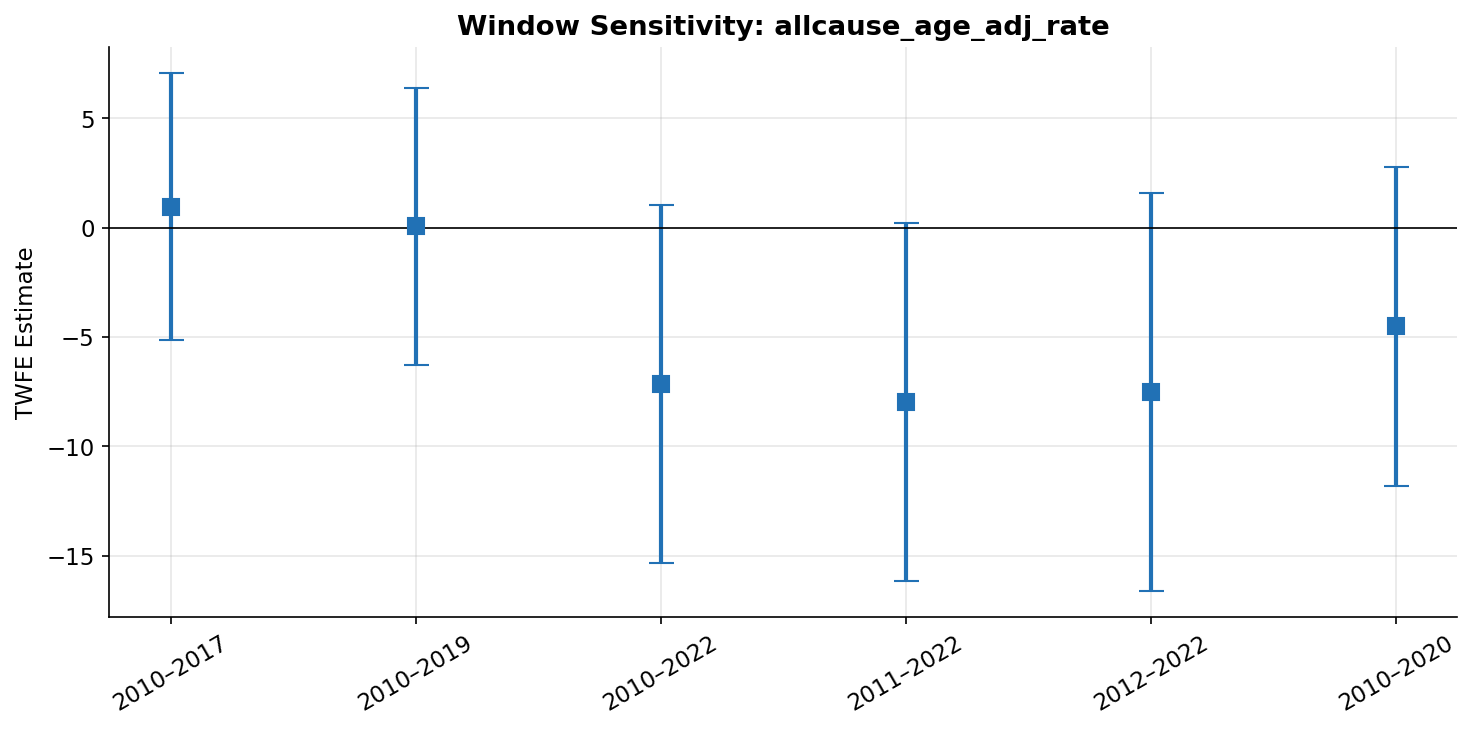

Saved: tables/window_sensitivity.csv


In [7]:
if PRIMARY_OUTCOME:
    windows = [
        (2010, 2017),  # Short post-period
        (2010, 2019),  # Medium
        (2010, 2022),  # Full sample
        (2011, 2022),  # Shorter pre-period
        (2012, 2022),  # Even shorter pre
        (2010, 2020),  # Exclude COVID years
    ]
    
    window_df = run_window_sensitivity(panel, PRIMARY_OUTCOME, windows)
    
    if len(window_df) > 0:
        print(f"Window Sensitivity: {PRIMARY_OUTCOME}")
        print("=" * 70)
        display(window_df.round(4))
        
        # Plot
        fig, ax = plt.subplots(figsize=(10, 5))
        x_pos = range(len(window_df))
        ax.errorbar(x_pos, window_df['coef'],
                    yerr=1.96 * window_df['se'],
                    fmt='s', color='#2171b5', capsize=6, markersize=8, linewidth=2)
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(window_df['window'], rotation=30)
        ax.set_ylabel('TWFE Estimate')
        ax.set_title(f'Window Sensitivity: {PRIMARY_OUTCOME}', fontweight='bold')
        
        plt.tight_layout()
        plt.savefig('../figures/window_sensitivity.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        window_df.to_csv('../tables/window_sensitivity.csv', index=False)
        print("Saved: tables/window_sensitivity.csv")
else:
    print("No outcome variable available.")

---
## 4. Permutation / Randomization Inference

Randomly reassign which states are "treated" and re-estimate. The distribution of placebo estimates provides a null distribution for inference.

In [8]:
def run_permutation_test(panel, outcome_var, n_permutations=500):
    """
    Randomly reassign treatment status and re-estimate.
    Returns distribution of placebo estimates.
    """
    np.random.seed(42)
    
    # Get list of states and their actual treatment status
    state_info = panel.groupby('state_fips')['ever_expanded'].first()
    n_treated = state_info.sum()
    all_states = state_info.index.tolist()
    
    placebo_estimates = []
    
    for i in range(n_permutations):
        # Randomly assign treatment
        fake_treated = np.random.choice(all_states, size=int(n_treated), replace=False)
        
        df = panel[panel[outcome_var].notna()].copy()
        df['fake_treat'] = df['state_fips'].isin(fake_treated).astype(int)
        df['fake_post'] = (df['year'] >= 2014).astype(int)
        df['fake_did'] = df['fake_treat'] * df['fake_post']
        
        try:
            model = smf.ols(
                f'{outcome_var} ~ fake_treat + fake_post + fake_did', data=df
            ).fit()
            placebo_estimates.append(model.params['fake_did'])
        except:
            pass
        
        if (i + 1) % 100 == 0:
            print(f"  Completed {i + 1}/{n_permutations} permutations")
    
    return np.array(placebo_estimates)

Running permutation test for: allcause_age_adj_rate
Running 500 permutations...



  Completed 100/500 permutations


  Completed 200/500 permutations


  Completed 300/500 permutations


  Completed 400/500 permutations


  Completed 500/500 permutations


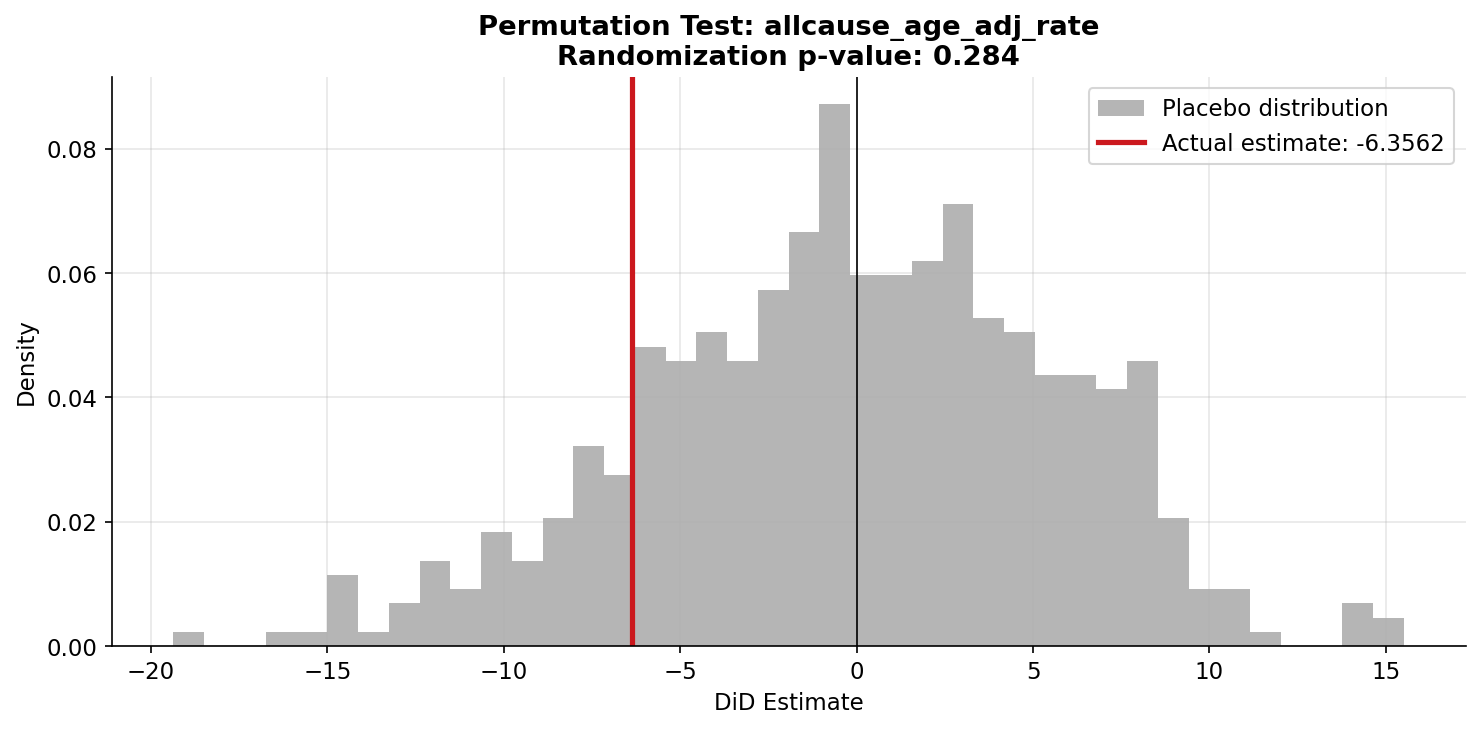


Actual estimate: -6.3562
Randomization p-value: 0.284
⚠️  Actual estimate is within the placebo distribution — may not be significant.


In [9]:
if PRIMARY_OUTCOME:
    print(f"Running permutation test for: {PRIMARY_OUTCOME}")
    print("Running 500 permutations...\n")
    
    placebo_dist = run_permutation_test(panel, PRIMARY_OUTCOME, n_permutations=500)
    
    # Get actual estimate
    df_actual = panel[
        (panel['expansion_year'].isin([2014, 0])) &
        (panel[PRIMARY_OUTCOME].notna())
    ].copy()
    df_actual['post'] = (df_actual['year'] >= 2014).astype(int)
    df_actual['treat'] = (df_actual['expansion_year'] == 2014).astype(int)
    df_actual['did'] = df_actual['treat'] * df_actual['post']
    actual_model = smf.ols(f'{PRIMARY_OUTCOME} ~ treat + post + did', data=df_actual).fit()
    actual_estimate = actual_model.params['did']
    
    # p-value from permutation distribution
    perm_pvalue = (np.abs(placebo_dist) >= np.abs(actual_estimate)).mean()
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(placebo_dist, bins=40, color='#969696', alpha=0.7,
            label='Placebo distribution', density=True)
    ax.axvline(x=actual_estimate, color='#cb181d', linewidth=2.5,
               label=f'Actual estimate: {actual_estimate:.4f}')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    
    ax.set_xlabel('DiD Estimate')
    ax.set_ylabel('Density')
    ax.set_title(f'Permutation Test: {PRIMARY_OUTCOME}\n'
                 f'Randomization p-value: {perm_pvalue:.3f}',
                 fontweight='bold')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig('../figures/permutation_test.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nActual estimate: {actual_estimate:.4f}")
    print(f"Randomization p-value: {perm_pvalue:.3f}")
    if perm_pvalue < 0.05:
        print("✅ Actual estimate is in the extreme tail — unlikely due to chance.")
    else:
        print("⚠️  Actual estimate is within the placebo distribution — may not be significant.")
else:
    print("No outcome variable available.")

---
## 5. Robustness Summary

In [10]:
print("\n" + "=" * 60)
print("ROBUSTNESS CHECK SUMMARY")
print("=" * 60)

checks = [
    ("Placebo tests", "figures/placebo_tests.png"),
    ("Leave-one-out", "figures/leave_one_out.png"),
    ("Window sensitivity", "figures/window_sensitivity.png"),
    ("Permutation test", "figures/permutation_test.png"),
]

for name, filepath in checks:
    exists = os.path.exists(f'../{filepath}')
    status = '✅' if exists else '⬜'
    print(f"  {status} {name}: {'Completed' if exists else 'Not yet run'}")

print("\nAdditional checks to implement:")
print("  ⬜ Alternative control groups (border states)")
print("  ⬜ Dose-response (coverage gains vs health effects)")
print("  ⬜ Bacon decomposition (see R/04_twfe_diagnostics.R)")
print("  ⬜ Callaway-Sant'Anna (see R/01_did_callaway_santanna.R)")
print("  ⬜ Sun & Abraham (see R/03_sun_abraham.R)")


ROBUSTNESS CHECK SUMMARY
  ✅ Placebo tests: Completed
  ✅ Leave-one-out: Completed
  ✅ Window sensitivity: Completed
  ✅ Permutation test: Completed

Additional checks to implement:
  ⬜ Alternative control groups (border states)
  ⬜ Dose-response (coverage gains vs health effects)
  ⬜ Bacon decomposition (see R/04_twfe_diagnostics.R)
  ⬜ Callaway-Sant'Anna (see R/01_did_callaway_santanna.R)
  ⬜ Sun & Abraham (see R/03_sun_abraham.R)


---
## Interpretation Guide

| Check | What it tests | Good result |
|-------|--------------|-------------|
| Placebo tests | No pre-existing trends | Insignificant fake-year estimates |
| Leave-one-out | No single state drives result | Estimate stable across dropped states |
| Window sensitivity | Robust to period definition | Consistent sign/significance across windows |
| Permutation test | Result not due to chance | Actual estimate in extreme tail of null |
| Bacon decomposition | TWFE bias from timing | Low weight on "bad comparisons" |
| CS / Sun-Abraham | Modern estimators agree | Similar magnitude to TWFE |